In [2]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src.backtesting import (
    compute_portfolio_returns,
    cumulative_returns,
    total_return,
    annualized_return,
    sharpe_ratio,
    max_drawdown
)


In [3]:
tsla = pd.read_csv("../data/processed/TSLA_cleaned.csv", parse_dates=["Date"], index_col="Date")
spy  = pd.read_csv("../data/processed/SPY_cleaned.csv",  parse_dates=["Date"], index_col="Date")
bnd  = pd.read_csv("../data/processed/BND_cleaned.csv",  parse_dates=["Date"], index_col="Date")


In [4]:
returns = pd.concat(
    [
        tsla["Return"].rename("TSLA"),
        spy["Return"].rename("SPY"),
        bnd["Return"].rename("BND")
    ],
    axis=1
).dropna()


C:\Users\derej\AppData\Local\Temp\ipykernel_6540\450416441.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  returns = pd.concat(


In [5]:
backtest_returns = returns.loc["2025-01-01":"2026-01-01"]


In [6]:
# Forecast-driven optimized portfolio (Task 4)
strategy_weights = {
    "TSLA": 0.05,   # example — replace with your real value
    "SPY": 0.90,
    "BND": 0.05
}

# Benchmark: 60/40 portfolio
benchmark_weights = {
    "TSLA": 0.0,
    "SPY": 0.6,
    "BND": 0.4
}


In [7]:
strategy_daily = compute_portfolio_returns(backtest_returns, strategy_weights)
benchmark_daily = compute_portfolio_returns(backtest_returns, benchmark_weights)


In [8]:
strategy_cum = cumulative_returns(strategy_daily)
benchmark_cum = cumulative_returns(benchmark_daily)


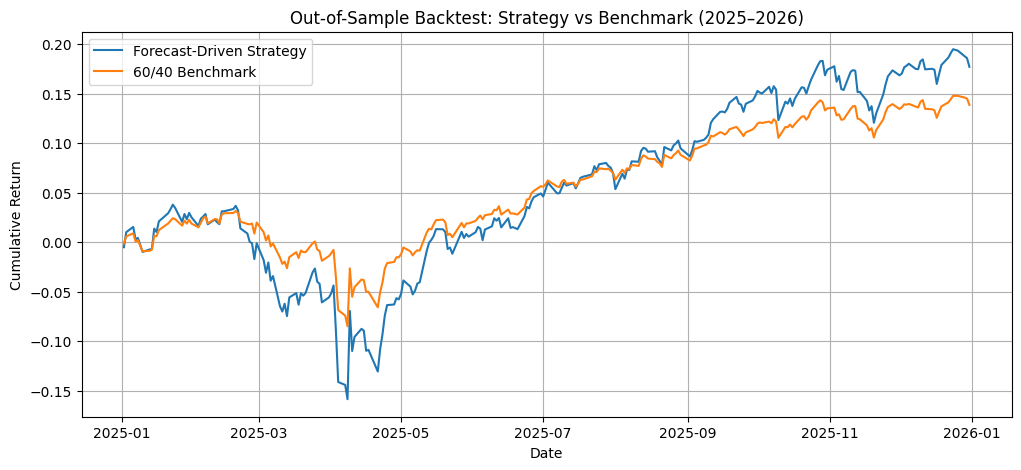

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(strategy_cum, label="Forecast-Driven Strategy")
plt.plot(benchmark_cum, label="60/40 Benchmark")
plt.title("Out-of-Sample Backtest: Strategy vs Benchmark (2025–2026)")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
metrics = pd.DataFrame({
    "Strategy": [
        total_return(strategy_daily),
        annualized_return(strategy_daily),
        sharpe_ratio(strategy_daily),
        max_drawdown(strategy_cum)
    ],
    "Benchmark (60/40)": [
        total_return(benchmark_daily),
        annualized_return(benchmark_daily),
        sharpe_ratio(benchmark_daily),
        max_drawdown(benchmark_cum)
    ]
}, index=[
    "Total Return",
    "Annualized Return",
    "Sharpe Ratio",
    "Max Drawdown"
])

metrics


,Strategy,Benchmark (60/40)
Total Return,0.177006,0.138525
Annualized Return,0.178541,0.139707
Sharpe Ratio,0.924840,1.150872
Max Drawdown,-0.189400,-0.112888
